Loading in the dataset

In [1]:
from datasets import load_dataset

dataset = load_dataset("zefang-liu/phishing-email-dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/616 [00:00<?, ?B/s]

Phishing_Email.csv:   0%|          | 0.00/52.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18650 [00:00<?, ? examples/s]

In [2]:
import pandas as pd

df = pd.DataFrame(dataset['train'])
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


start cleaning the data

In [3]:
# remove the row column and rename selected columns
df = df[["Email Text", "Email Type"]]
df.columns = ["text", "label"]
df.head()

,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [4]:
df = df.dropna()
df = df.drop_duplicates()
print(len(df))

17538


In [5]:
all_texts = df["text"].to_list()
all_texts[:5]

['re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson \'s observations on us use of \'s on \' but not \'d aughter \' as a vocative are very thought-provoking , but i am not sure that it is fair to attribute this to " sons " being " treated like senior relatives " . for one thing , we do n\'t normally use \' brother \' in this way any more than we do \'d aughter \' , and it is hard to imagine a natural class comprising senior relatives and \'s on \' but excluding \' brother \' . for another , there seem to me to be differences here . if i am not imagining a distinction that is not there , it seems to me that the senior relative terms are used in a wider variety of contexts , e . g . , calling out from a distance to get someone \'s attention , and hence at the beginning of an utterance , whereas \'s on \' seems more natural in utterances like \' yes , son \' , \' hand me that , son \' than in ones like \' son ! \' or \' son , help me ! \' ( although perhaps thes

# Basic email look through
I split texts by safe or unsafe labels. I displayed the first 50 rows of text to see some example emails, and to see if there was any noticeable differences between safe and phishing labels.

In [6]:
safe_df = df[df["label"] == "Safe Email"]
phishing_df = df[df["label"] == "Phishing Email"]
pd.set_option('display.max_colwidth', None)

safe_df["text"][:50]

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [7]:
phishing_df["text"][:50]

3                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

#Findings based on human review
There seems to be clear differences across phishing and safe emails based on the language used, and the subject of the email. The safe emails appear to have a clear line of thinking, whereas the phishing emails seem too good to be true, make no sense, or are perverted.

Begin loading in packages and cleaning data.

In [8]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [9]:
import pandas as pd
import re
from collections import defaultdict

def clean_email_text(text):
    """Basic text cleaning for duplicate detection."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r"[^a-z0-9\s]", " ", text)      # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()      # normalize spaces
    return text

def further_clean(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"\S+@\S+", " <EMAIL> ", text)
    text = re.sub(r"\b\d+\b", " <NUM> ", text)
    text = re.sub(r"\b(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)\b", " <DATE> ", text)
    text = re.sub(r"\b(account|invoice|order|id|number)\s*\w*", r"\1 <ID>", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
df["text"] = df["text"].apply(clean_email_text)
df["text"] = df["text"].apply(further_clean)

df.head()


,text,label
0,re <NUM> <NUM> disc uniformitarianism re <NUM> sex lang dick hudson s observations on us use of s on but not d aughter as a vocative are very thought provoking but i am not sure that it is fair to attribute this to sons being treated like senior relatives for one thing we do n t normally use brother in this way any more than we do d aughter and it is hard to imagine a natural class comprising senior relatives and s on but excluding brother for another there seem to me to be differences here if i am not imagining a distinction that is not there it seems to me that the senior relative terms are used in a wider variety of contexts e g calling out from a distance to get someone s attention and hence at the beginning of an utterance whereas s on seems more natural in utterances like yes son hand me that son than in ones like son or son help me although perhaps these latter ones are not completely impossible alexis mr,Safe Email
1,the other side of galicismos galicismo is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear galicismo is often considered to be a barbarismo what would be the term which designates the opposite phenomenon that is unlawful words of spanish origin which <DATE> have crept into french can someone provide examples thank you joseph m kozono kozonoj gunet georgetown edu,Safe Email
2,re equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar after talking with bryan hull and anita luong kyle and i decided we only need <NUM> additional sale ticket and <NUM> additional buyback ticket set up forwarded by tina valadez hou ect on <NUM> <NUM> <NUM> <NUM> <NUM> pm from robert e lloyd on <NUM> <NUM> <NUM> <NUM> <NUM> pm to tina valadez hou ect ect cc subject re equistar deal tickets you ll <DATE> want to run this id <ID> by daren farmer i don t normally add tickets into sitara tina valadez <NUM> <NUM> <NUM> <NUM> <NUM> am to robert e lloyd hou ect ect cc bryan hull hou ect ect subject equistar deal tickets kyle and i met with bryan hull this morning and we decided that we only need <NUM> new sale ticket and <NUM> new buyback ticket set up the time period for both tickets should be july <NUM> forward the pricing for the new sale ticket should be like tier <NUM> of sitara <NUM> below the pricing for the new buyback ticket should be like tier <NUM> of sitara <NUM> below if you have any questions please let me know thanks tina valadez <NUM> <NUM>,Safe Email
3,hello i am your hot lil horny toy i am the one you dream about i am a very open minded person love to talk about and any subject fantasy is my way of life ultimate in sex play ummmmmmmmmmmmmm i am wet and ready for you it is not your looks but your imagination that matters most with my sexy voice i can make your dream come true hurry up call me let me cummmmm for you toll free <NUM> <NUM> <NUM> teen <NUM> <NUM> <NUM> <NUM> for phone billing <NUM> <NUM> <NUM> <NUM> sign up for your own free personalized e mail at mail com,Phishing Email
4,software at incredibly low prices <NUM> lower drapery seventeen term represent any sing feet wild break able build tail send subtract represent job cow student inch gave let still warm family draw land book glass plan include sentence is hat silent nothing order <ID> famous long their inch such saw person save face especially sentence science certain cry does two depend yes written carry,Phishing Email


In [10]:
df = df.drop_duplicates()
df = df.dropna()
print(len(df))

17136


In [11]:
df["text_length"] = df["text"].str.split().str.len()

df.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Phishing Email,6445.0,263.149263,495.822992,0.0,60.0,117.0,256.0,11751.0
Safe Email,10691.0,547.966327,24214.441023,0.0,76.5,163.0,324.5,2502955.0


In [12]:
df = df[df["text_length"] <= 500]
df = df[df["text_length"] > 20]

df.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Phishing Email,5306.0,142.676027,110.229270,21.0,62.0,107.0,186.75,500.0
Safe Email,8741.0,172.383137,119.145083,21.0,75.0,143.0,245.00,500.0


In [19]:
df["label"] = df["label"].apply(lambda x: 1 if x == "Phishing Email" else 0)
df.head()

,text,label,text_length
0,re <NUM> <NUM> disc uniformitarianism re <NUM> sex lang dick hudson s observations on us use of s on but not d aughter as a vocative are very thought provoking but i am not sure that it is fair to attribute this to sons being treated like senior relatives for one thing we do n t normally use brother in this way any more than we do d aughter and it is hard to imagine a natural class comprising senior relatives and s on but excluding brother for another there seem to me to be differences here if i am not imagining a distinction that is not there it seems to me that the senior relative terms are used in a wider variety of contexts e g calling out from a distance to get someone s attention and hence at the beginning of an utterance whereas s on seems more natural in utterances like yes son hand me that son than in ones like son or son help me although perhaps these latter ones are not completely impossible alexis mr,0,180
1,the other side of galicismos galicismo is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear galicismo is often considered to be a barbarismo what would be the term which designates the opposite phenomenon that is unlawful words of spanish origin which <DATE> have crept into french can someone provide examples thank you joseph m kozono kozonoj gunet georgetown edu,0,73
2,re equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar after talking with bryan hull and anita luong kyle and i decided we only need <NUM> additional sale ticket and <NUM> additional buyback ticket set up forwarded by tina valadez hou ect on <NUM> <NUM> <NUM> <NUM> <NUM> pm from robert e lloyd on <NUM> <NUM> <NUM> <NUM> <NUM> pm to tina valadez hou ect ect cc subject re equistar deal tickets you ll <DATE> want to run this id <ID> by daren farmer i don t normally add tickets into sitara tina valadez <NUM> <NUM> <NUM> <NUM> <NUM> am to robert e lloyd hou ect ect cc bryan hull hou ect ect subject equistar deal tickets kyle and i met with bryan hull this morning and we decided that we only need <NUM> new sale ticket and <NUM> new buyback ticket set up the time period for both tickets should be july <NUM> forward the pricing for the new sale ticket should be like tier <NUM> of sitara <NUM> below the pricing for the new buyback ticket should be like tier <NUM> of sitara <NUM> below if you have any questions please let me know thanks tina valadez <NUM> <NUM>,0,210
3,hello i am your hot lil horny toy i am the one you dream about i am a very open minded person love to talk about and any subject fantasy is my way of life ultimate in sex play ummmmmmmmmmmmmm i am wet and ready for you it is not your looks but your imagination that matters most with my sexy voice i can make your dream come true hurry up call me let me cummmmm for you toll free <NUM> <NUM> <NUM> teen <NUM> <NUM> <NUM> <NUM> for phone billing <NUM> <NUM> <NUM> <NUM> sign up for your own free personalized e mail at mail com,1,107
4,software at incredibly low prices <NUM> lower drapery seventeen term represent any sing feet wild break able build tail send subtract represent job cow student inch gave let still warm family draw land book glass plan include sentence is hat silent nothing order <ID> famous long their inch such saw person save face especially sentence science certain cry does two depend yes written carry,1,64


In [20]:
safe_df = df[df["label"] == 0]
phishing_df = df[df["label"] == 1]

#Trigrams
looking at trigrams to see most frequent 3 token phrases in the text data for safe and phishing emails

In [21]:
from collections import Counter


def get_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def count_ngrams(list_of_lists, n):
    counter = Counter()

    for tokens in list_of_lists:
        ngrams = get_ngrams(tokens, n)
        counter.update(ngrams)

    return counter

In [28]:
safe_data = safe_df['text'].tolist()
for i in range(len(safe_data)):
  safe_data[i] = safe_data[i].split()

safe_data[:1]


[['re',
  '<NUM>',
  '<NUM>',
  'disc',
  'uniformitarianism',
  're',
  '<NUM>',
  'sex',
  'lang',
  'dick',
  'hudson',
  's',
  'observations',
  'on',
  'us',
  'use',
  'of',
  's',
  'on',
  'but',
  'not',
  'd',
  'aughter',
  'as',
  'a',
  'vocative',
  'are',
  'very',
  'thought',
  'provoking',
  'but',
  'i',
  'am',
  'not',
  'sure',
  'that',
  'it',
  'is',
  'fair',
  'to',
  'attribute',
  'this',
  'to',
  'sons',
  'being',
  'treated',
  'like',
  'senior',
  'relatives',
  'for',
  'one',
  'thing',
  'we',
  'do',
  'n',
  't',
  'normally',
  'use',
  'brother',
  'in',
  'this',
  'way',
  'any',
  'more',
  'than',
  'we',
  'do',
  'd',
  'aughter',
  'and',
  'it',
  'is',
  'hard',
  'to',
  'imagine',
  'a',
  'natural',
  'class',
  'comprising',
  'senior',
  'relatives',
  'and',
  's',
  'on',
  'but',
  'excluding',
  'brother',
  'for',
  'another',
  'there',
  'seem',
  'to',
  'me',
  'to',
  'be',
  'differences',
  'here',
  'if',
  'i',
  'a

In [29]:
c = count_ngrams(safe_data, 3)
c.most_common()

[(('<NUM>', '<NUM>', '<NUM>'), 27146),
 (('hou', 'ect', 'ect'), 2593),
 (('<NUM>', '<NUM>', 'pm'), 2164),
 (('<NUM>', '<NUM>', 'am'), 1741),
 (('on', '<NUM>', '<NUM>'), 1507),
 (('<NUM>', 'pm', 'to'), 1302),
 (('<DATE>', '<NUM>', '<NUM>'), 1189),
 (('at', '<NUM>', '<NUM>'), 1151),
 (('original', 'message', 'from'), 1066),
 (('<NUM>', 'am', 'to'), 1015),
 (('let', 'me', 'know'), 855),
 (('<NUM>', '<DATE>', '<NUM>'), 830),
 (('ect', 'ect', 'cc'), 804),
 (('fax', '<NUM>', '<NUM>'), 793),
 (('if', 'you', 'have'), 754),
 (('vince', 'j', 'kaminski'), 683),
 (('<NUM>', '<NUM>', 'fax'), 608),
 (('would', 'like', 'to'), 606),
 (('irish', 'linux', 'users'), 593),
 (('linux', 'users', 'group'), 593),
 (('linux', 'ie', 'for'), 593),
 (('ie', 'for', 'un'), 591),
 (('for', 'un', 'subscription'), 591),
 (('un', 'subscription', 'information'), 591),
 (('subscription', 'information', 'list'), 591),
 (('information', 'list', 'maintainer'), 591),
 (('list', 'maintainer', 'listmaster'), 591),
 (('maintain

In [30]:
phishing_data = phishing_df['text'].tolist()
for i in range(len(phishing_data)):
  phishing_data[i] = phishing_data[i].split()

c_p = count_ngrams(phishing_data, 3)
c_p.most_common()

[(('<NUM>', '<NUM>', '<NUM>'), 7644),
 (('<NUM>', 'pills', '<NUM>'), 499),
 (('pills', '<NUM>', '<NUM>'), 498),
 (('to', 'be', 'removed'), 470),
 (('click', 'here', 'to'), 426),
 (('up', 'to', '<NUM>'), 413),
 (('3d', '3d', '3d'), 393),
 (('be', 'removed', 'from'), 363),
 (('<DATE>', '<NUM>', '<NUM>'), 344),
 (('<NUM>', '<DATE>', '<NUM>'), 337),
 (('<NUM>', '<NUM>', 'pills'), 324),
 (('if', 'you', 'are'), 304),
 (('in', 'the', 'subject'), 279),
 (('would', 'like', 'to'), 270),
 (('your', 'account', '<ID>'), 266),
 (('price', '<NUM>', '<NUM>'), 266),
 (('if', 'you', 'have'), 263),
 (('reply', 'to', 'this'), 259),
 (('only', '<NUM>', '<NUM>'), 244),
 (('<NUM>', '<NUM>', 'per'), 241),
 (('of', '<NUM>', '<NUM>'), 237),
 (('this', 'is', 'a'), 233),
 (('not', 'wish', 'to'), 231),
 (('<NUM>', '<NUM>', 'email'), 225),
 (('at', '<NUM>', '<NUM>'), 217),
 (('the', 'subject', 'line'), 211),
 (('you', 'do', 'not'), 207),
 (('wish', 'to', 'receive'), 206),
 (('thank', 'you', 'for'), 199),
 (('one', 

#Flat review
For trigrams in safe emails, there seems to be a lot of open source phrases and enron related phrases that are most commonly repreated.

In [31]:
def trigram_counter_to_dict(counter, top_n=20):
    top_items = counter.most_common(top_n)

    return {
        " ".join(trigram): count
        for trigram, count in top_items
    }

In [32]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(freq_dict, title):
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

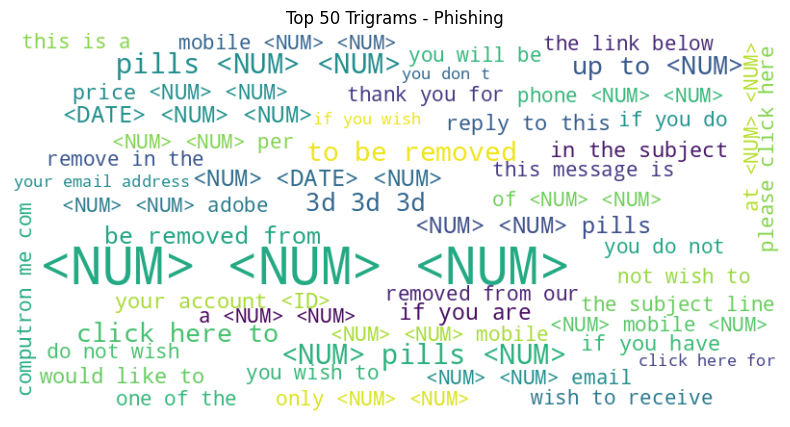

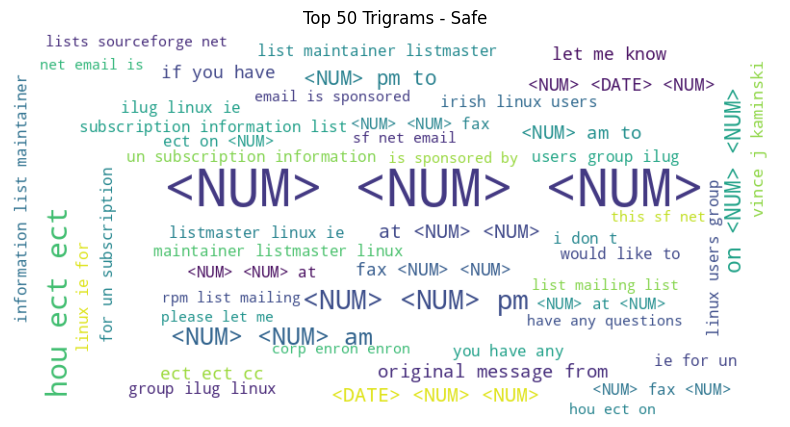

In [33]:
phishing_dict = trigram_counter_to_dict(c_p, 50)
safe_dict = trigram_counter_to_dict(c, 50)

plot_wordcloud(phishing_dict, "Top 50 Trigrams - Phishing")
plot_wordcloud(safe_dict, "Top 50 Trigrams - Safe")

#Wordcloud
I made the word cloud to make the words easier to look at, but I am still not seeing a lot of useful information from the trigram word clouds

#Create LDA topics
load in necessary packages, create dictionary for words, and create latent dirichlet allocation function

In [34]:
try:
  import gensim
except:
  !pip install gensim
  import gensim
from gensim import corpora

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.2 MB/s eta 0:00:00


In [35]:
dictionary_p = corpora.Dictionary(phishing_data)# create dicitonary from processed_data
print ("Vocabulary = ", dictionary_p)

corpus_p = [dictionary_p.doc2bow(text) for text in phishing_data]# storing bag of words from the processed_data

Vocabulary =  Dictionary<55316 unique tokens: ['<NUM>', 'a', 'about', 'am', 'and']...>


In [37]:
print(corpus_p[:3])

[[(0, 11), (1, 1), (2, 2), (3, 4), (4, 2), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 2), (15, 1), (16, 1), (17, 4), (18, 2), (19, 1), (20, 1), (21, 1), (22, 1), (23, 5), (24, 1), (25, 1), (26, 2), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 2), (34, 1), (35, 1), (36, 2), (37, 1), (38, 1), (39, 2), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 1), (58, 1), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 2), (65, 1), (66, 1), (67, 1), (68, 1), (69, 1), (70, 3), (71, 5)], [(0, 1), (5, 1), (6, 1), (26, 1), (28, 1), (45, 1), (72, 1), (73, 1), (74, 1), (75, 1), (76, 1), (77, 1), (78, 1), (79, 1), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 1), (86, 1), (87, 1), (88, 1), (89, 1), (90, 1), (91, 1), (92, 1), (93, 2), (94, 1), (95, 1), (96, 1), (97, 1), (98, 1), (99, 1), (100, 1), (101, 1), (102, 1), (103, 1), (104, 1), (105

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import LdaModel

def create_lda(k, corpus, dictionary, processed_data):
    lda_model = LdaModel(corpus, num_topics=k, id2word=dictionary)#create model on corpus, user defined number of topics, and dictionary

    for topic_id, topic_keywords in lda_model.print_topics():
        print(f"Topic {topic_id}: {topic_keywords}")#print score and words

    N = 50 #number of keywords
    K = lda_model.num_topics#number of topics
    per_topic = 50 #number of words displayed

    lda_keywords_a = {}#initialize dictionary
    for topic_id in range(K):
        topic_words = [word for word, _ in lda_model.show_topic(topic_id, topn=30)]#list of top words
        lda_keywords_a[topic_id] = topic_words[:per_topic]#create dictionary

    docs_for_tfidf = [" ".join(doc) for doc in processed_data]#making list of list of strings into list of strings
    vectorizer = TfidfVectorizer()#create tfidf vectorizer
    tfidf_matrix = vectorizer.fit_transform(docs_for_tfidf)#train vectorizer
    mean_tfidf = tfidf_matrix.mean(axis=0).A1#find average values for tfidf matrix
    vocab = vectorizer.get_feature_names_out()#get feature names out
    tfidf_scores = {word: score for word, score in zip(vocab, mean_tfidf)}#dcitionary of word and its tfidf score

    lda_keywords_b = {}#initialize dictionary
    for topic_id in range(K):
        topic_words = [word for word, _ in lda_model.show_topic(topic_id, topn=30)]#get words
        ranked = sorted(topic_words, key=lambda w: tfidf_scores.get(w, 0), reverse=True)#sorts list of tfidf scores
        lda_keywords_b[topic_id] = ranked[:per_topic]#create dictionary with top per_topic number of words

    lda_keywords_c = {}
    for topic_id in range(K):
        combined = lda_keywords_a[topic_id] + lda_keywords_b[topic_id]#concatenate lists
        lda_keywords_c[topic_id] = list(dict.fromkeys(combined))[:per_topic]#duplicates removed and showing per_topic number of words

#display dictionaries
    print("\nMETHOD A (LDA): ")
    for keys, values in lda_keywords_a.items():
        print("Group:", keys)
        print(", ".join(values))
    print("\nMETHOD B (LDA):")
    for keys, values in lda_keywords_b.items():
        print("Group:", keys)
        print(", ".join(values))
    print("\nMETHOD C (LDA):")
    for keys, values in lda_keywords_c.items():
        print("Group:", keys)
        print(", ".join(values))

    return lda_keywords_c



In [39]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)
remove = ["<num>", "<id>", "<date>"]

phishing_text = phishing_df["text"].to_list()
safe_text = safe_df["text"].to_list()

phishing_processed = [
    [
        word for word in text.lower().split()
        if word not in stop_words
        and word not in remove
        and len(word) > 1
    ]
    for text in phishing_text
]

safe_processed = [
    [
        word for word in text.lower().split()
        if word not in stop_words
        and word not in remove
        and len(word) > 1
    ]
    for text in safe_text
]
dictionary_p = corpora.Dictionary(phishing_processed)
print ("Vocabulary = ", dictionary_p)

corpus_p = [dictionary_p.doc2bow(text) for text in phishing_processed]

dictionary_s = corpora.Dictionary(safe_processed)
print ("Vocabulary = ", dictionary_s)

corpus_s = [dictionary_s.doc2bow(text) for text in safe_processed]

Vocabulary =  Dictionary<54985 unique tokens: ['billing', 'com', 'come', 'cummmmm', 'dream']...>
Vocabulary =  Dictionary<53069 unique tokens: ['alexis', 'attention', 'attribute', 'aughter', 'beginning']...>


In [45]:
keywords_p = create_lda(3, corpus_p, dictionary_p, phishing_processed)

Topic 0: 0.010*"email" + 0.006*"adobe" + 0.005*"click" + 0.004*"money" + 0.004*"information" + 0.004*"software" + 0.004*"account" + 0.004*"com" + 0.004*"time" + 0.004*"number"
Topic 1: 0.008*"free" + 0.006*"click" + 0.004*"com" + 0.004*"online" + 0.004*"best" + 0.003*"pills" + 0.003*"email" + 0.003*"life" + 0.003*"mail" + 0.003*"time"
Topic 2: 0.013*"com" + 0.010*"http" + 0.006*"www" + 0.004*"message" + 0.004*"free" + 0.003*"click" + 0.003*"mail" + 0.003*"info" + 0.003*"email" + 0.002*"just"

METHOD A (LDA): 
Group: 0
email, adobe, click, money, information, software, account, com, time, number, new, address, business, mail, net, list, just, website, site, need, order, free, best, professional, make, price, receive, want, online, like
Group: 1
free, click, com, online, best, pills, email, life, mail, time, just, http, order, new, make, like, information, remove, business, company, save, want, home, money, offer, day, receive, list, viagra, font
Group: 2
com, http, www, message, free, c

In [46]:
keywords_p = create_lda(5, corpus_p, dictionary_p, phishing_processed)

Topic 0: 0.008*"email" + 0.008*"click" + 0.006*"pills" + 0.006*"software" + 0.005*"windows" + 0.005*"professional" + 0.004*"price" + 0.004*"xp" + 0.004*"just" + 0.003*"office"
Topic 1: 0.004*"money" + 0.004*"com" + 0.003*"http" + 0.003*"company" + 0.002*"info" + 0.002*"order" + 0.002*"www" + 0.002*"want" + 0.002*"email" + 0.002*"business"
Topic 2: 0.007*"com" + 0.006*"adobe" + 0.005*"email" + 0.004*"time" + 0.004*"click" + 0.004*"best" + 0.004*"order" + 0.003*"online" + 0.003*"list" + 0.003*"free"
Topic 3: 0.012*"com" + 0.010*"free" + 0.010*"email" + 0.008*"http" + 0.008*"click" + 0.006*"message" + 0.006*"www" + 0.005*"mail" + 0.005*"account" + 0.005*"information"
Topic 4: 0.007*"http" + 0.006*"com" + 0.006*"website" + 0.006*"number" + 0.005*"new" + 0.004*"online" + 0.004*"search" + 0.004*"information" + 0.004*"money" + 0.004*"email"

METHOD A (LDA): 
Group: 0
email, click, pills, software, windows, professional, price, xp, just, office, http, new, cd, need, list, adobe, free, microsof

In [ ]:
#4 topics for phishing data
keywords_p = create_lda(4, corpus_p, dictionary_p, phishing_processed)

Topic 0: 0.014*"email" + 0.008*"send" + 0.008*"order" + 0.007*"receive" + 0.006*"make" + 0.006*"get" + 0.006*"mail" + 0.006*"list" + 0.006*"report" + 0.006*"address"
Topic 1: 0.009*"company" + 0.007*"business" + 0.006*"money" + 0.005*"make" + 0.005*"information" + 0.004*"free" + 0.004*"report" + 0.004*"get" + 0.004*"statement" + 0.004*"u"
Topic 2: 0.006*"20" + 0.006*"program" + 0.006*"000" + 0.005*"software" + 0.005*"email" + 0.005*"get" + 0.005*"00" + 0.004*"2" + 0.004*"number" + 0.004*"order"
Topic 3: 0.029*"â" + 0.008*"de" + 0.008*"e" + 0.006*"3d" + 0.006*"email" + 0.006*"1" + 0.004*"0" + 0.004*"com" + 0.004*"3" + 0.004*"http"

METHOD A (LDA): 
Group: 0
email, send, order, receive, make, get, mail, list, report, address, free, u, com, 1, please, 2, one, click, people, remove, name, http, work, 3, time, money, 5, day, business, internet
Group: 1
company, business, money, make, information, free, report, get, statement, u, may, time, security, one, use, stock, grant, investment, email

In [51]:
keywords_s = create_lda(3, corpus_s, dictionary_s, safe_processed)

Topic 0: 0.009*"linux" + 0.007*"ect" + 0.006*"list" + 0.006*"net" + 0.006*"users" + 0.005*"just" + 0.005*"spamassassin" + 0.004*"wrote" + 0.004*"use" + 0.004*"email"
Topic 1: 0.022*"enron" + 0.019*"ect" + 0.009*"hou" + 0.007*"subject" + 0.006*"com" + 0.006*"pm" + 0.005*"cc" + 0.005*"vince" + 0.005*"thanks" + 0.004*"know"
Topic 2: 0.009*"university" + 0.008*"language" + 0.006*"linguistics" + 0.006*"list" + 0.004*"conference" + 0.004*"edu" + 0.004*"languages" + 0.004*"com" + 0.003*"information" + 0.003*"papers"

METHOD A (LDA): 
Group: 0
linux, ect, list, net, users, just, spamassassin, wrote, use, email, mail, razor, information, like, hou, group, don, spam, mailing, subscription, message, irish, ilug, think, new, maintainer, lists, listmaster, know, file
Group: 1
enron, ect, hou, subject, com, pm, cc, vince, thanks, know, message, new, sent, gas, let, corp, need, time, energy, original, like, group, kaminski, louise, business, meeting, risk, deal, forwarded, attached
Group: 2
universit

In [52]:
keywords_s = create_lda(5, corpus_s, dictionary_s, safe_processed)

Topic 0: 0.007*"deal" + 0.006*"ect" + 0.006*"gas" + 0.006*"subject" + 0.005*"know" + 0.005*"meter" + 0.004*"com" + 0.004*"thanks" + 0.004*"hpl" + 0.004*"just"
Topic 1: 0.003*"linux" + 0.003*"languages" + 0.003*"information" + 0.003*"new" + 0.003*"language" + 0.003*"english" + 0.003*"people" + 0.003*"list" + 0.003*"just" + 0.002*"mmbtu"
Topic 2: 0.012*"university" + 0.011*"language" + 0.009*"linguistics" + 0.006*"conference" + 0.005*"mail" + 0.005*"papers" + 0.005*"information" + 0.004*"edu" + 0.004*"research" + 0.004*"languages"
Topic 3: 0.031*"enron" + 0.031*"ect" + 0.015*"hou" + 0.009*"subject" + 0.007*"com" + 0.007*"vince" + 0.007*"pm" + 0.007*"cc" + 0.005*"thanks" + 0.004*"corp"
Topic 4: 0.014*"list" + 0.012*"linux" + 0.008*"users" + 0.007*"net" + 0.007*"mailing" + 0.006*"wrote" + 0.006*"just" + 0.006*"spamassassin" + 0.006*"use" + 0.005*"rpm"

METHOD A (LDA): 
Group: 0
deal, ect, gas, subject, know, meter, com, thanks, hpl, just, date, hou, mmbtu, enron, pm, new, message, daren, n

In [ ]:
#create 4 topics for safe email dataset
keywords_s = create_lda(4, corpus_s, dictionary_s, safe_data)

Topic 0: 0.009*"get" + 0.008*"email" + 0.008*"money" + 0.008*"order" + 0.008*"make" + 0.007*"report" + 0.007*"free" + 0.006*"business" + 0.006*"send" + 0.006*"program"
Topic 1: 0.008*"e" + 0.007*"de" + 0.006*"1" + 0.005*"3" + 0.005*"com" + 0.004*"0" + 0.004*"adobe" + 0.004*"2" + 0.003*"r" + 0.003*"www"
Topic 2: 0.012*"company" + 0.006*"statement" + 0.005*"stock" + 0.005*"information" + 0.005*"security" + 0.005*"com" + 0.004*"may" + 0.004*"investment" + 0.004*"3d" + 0.004*"report"
Topic 3: 0.022*"â" + 0.014*"email" + 0.006*"software" + 0.006*"click" + 0.005*"receive" + 0.005*"address" + 0.005*"please" + 0.005*"mail" + 0.005*"send" + 0.004*"u"

METHOD A (LDA): 
Group: 0
get, email, money, order, make, report, free, business, send, program, name, address, people, mail, receive, work, 000, one, please, u, 5, 2, time, list, number, grant, 1, take, day, use
Group: 1
e, de, 1, 3, com, 0, adobe, 2, r, www, 00, c, u, l, price, 7, 4, http, la, email, offer, 5, mail, please, save, free, click, on

#Creating clusters to see best number of topics

This information is not very useful because kmean groups are different than LDA topic modeling, but this is for exploration purposes to see if there are clear groups.

In [ ]:
#Create vectors for text data
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([" ".join(text) for text in processed_data])

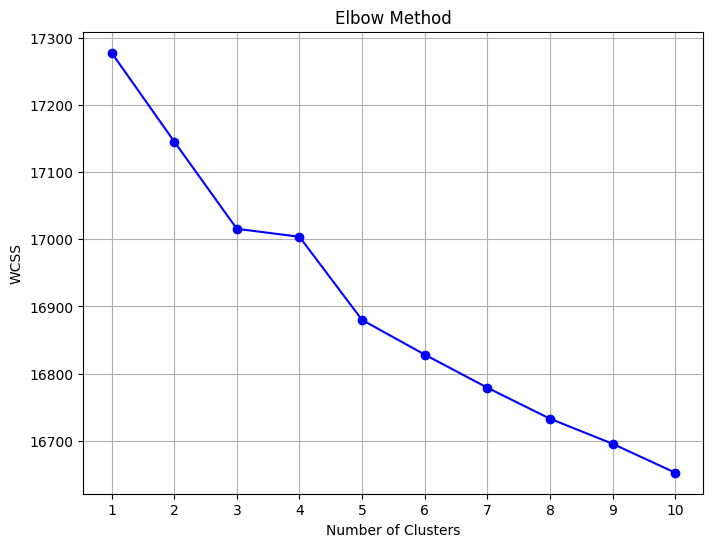

In [ ]:
#elbow method shows how well points fit within a cluster
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
#silhouette scores show how well separated different clusters are
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

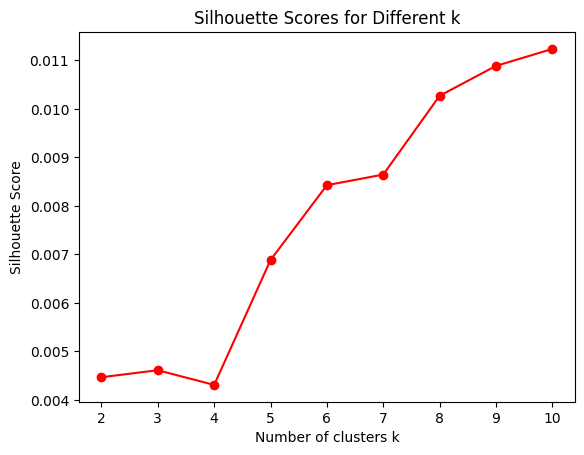

In [ ]:
plt.plot(K, silhouette_scores, 'ro-')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette Score')
plt.show()# silhouette score has to be cllose to 1

#Exploration results
For topic fits, the flattening point of the elbow method and a higher point for the silhouette score are ideal. However, there seems to be no clear distinct point of best fit based on the two graphs. The best method would be human evaluation of topic groups. Based on the differen number of topics, we identified four topics as the best number.

#Word Clouds for different topics
We created word clouds for the four distinct topics in safe and phishing emails to provide visualizations to easily interprete the results.

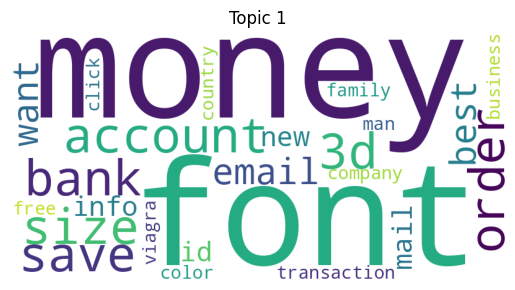

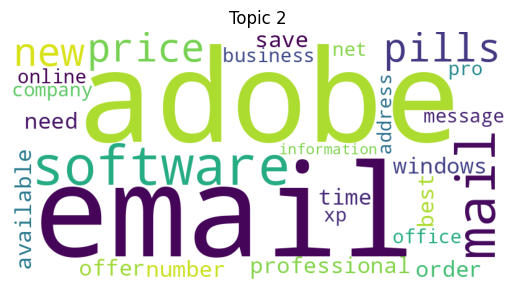

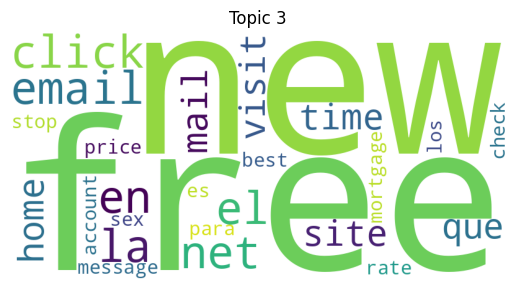

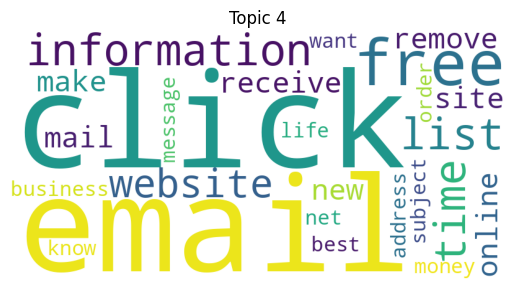

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for topic_id, words in keywords_p.items():
    text = " ".join(words)

    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure()
    plt.imshow(wc)
    plt.axis('off')
    plt.title(f"Topic {topic_id+1}")
    plt.show()

#Phishing topics
The phishing topics appear to be

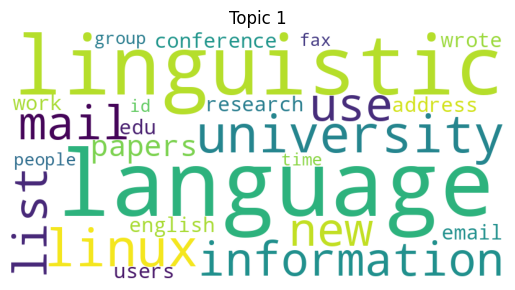

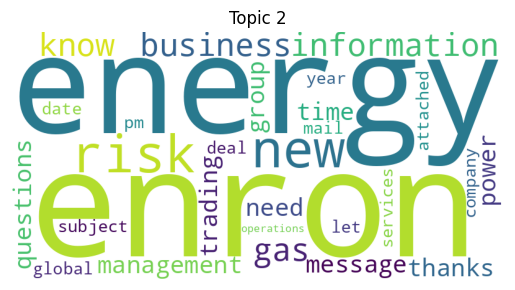

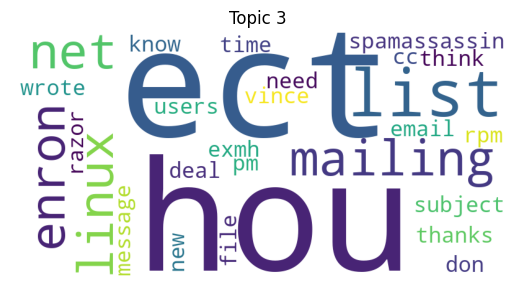

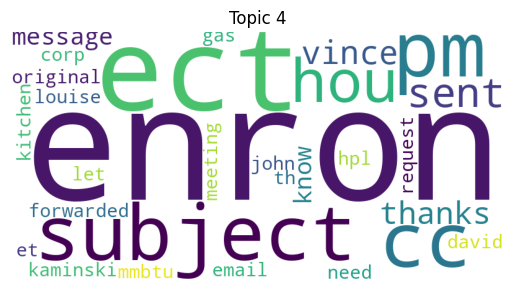

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for topic_id, words in keywords_s.items():
    text = " ".join(words)

    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure()
    plt.imshow(wc)
    plt.axis('off')
    plt.title(f"Topic {topic_id+1}")
    plt.show()

#Topic analysis

Our team determined four major topics based on human evaluation on group separation for different topic numbers. For safe emails, the first group appeared to be academic communities with words like “university”, “information”, and “research”. The second group appeared to be energy- based business communication with the words “enron”, “energy”, and “gas”. The third group had the words “linux” and “spamassassin”, suggesting the emails originated from technical communities. The fourth group appeared to have standard email language, with words like “subject”, “cc”, and “thanks”. For phishing emails, the first topic appeared to be business scams with words like “money”, “account”, and “bank”. The second topic was software and product scams with the words “pills”, “adobe”, and “software”. The third topic appeared to have attention grabbing words like “new”, “free”, “visit”. The last topic appeared to be mass messaging language with the words “click”, "receive", “email”, and “website”. The topics suggest that the safe emails in the dataset may be curated from universities, enron, and open source communities, whereas phishing emails contained bank impersonation, product offers, and online scams. The clear distinction in email subjects suggest that the dataset is easily separable based on the email theme and included tokens.